Safety in different locations is heavily influenced by population density.  Locations with high population density usually have high rates of crime and accidents due to the fact that highly population dense sections have more people.  On the opposite side, locations with low population density usually have low rates of crime and accidents which help create a safer environment.

This section of the project focuses population density in different locations of the city.  By analyzing the values of population density, I can determine what regions will most likely be more safe.

## Import pandas and initialize the dataset.

In [13]:
import pandas as pd

pop = pd.read_csv("population.csv")


## List of all collumn names

In [14]:
names = pop.columns.tolist()
for name in names:
    print(name)
print()

Neighborhood
Sector #
Pop. 1940
Pop. 1950
Pop. 1960
Pop. 1970
Pop. 1980
Pop. 1990
Pop. 2000
Pop. 2010
% Pop. Change, 60-70
% Pop. Change, 70-80
% Pop. Change, 80-90
% Pop. Change, 90-00
% Pop. Change, 00-10
Pop. as % of City total (2010)
Land Area (sq. mi)
Land Area (acres)
Persons / sq. mi (2010)
Persons / sq. mi (2000)
Persons / acre (2010)
Persons / acre (2000)
% African American (2010)
% Asian (2010)
% Other (2010)
% White (2010)
% 2+ Races (2010)
% Hispanic (of any race) (2010)
% Pop. Age < 5 (2010)
% Pop. Age 5-19 (2010)
% Pop. Age 20-34 (2010)
% Pop. Age 35-59 (2010)
% Pop. Age 60-74 (2010)
% Pop. Age > 75 (2010)



**Initialize population density dict.**  
*Organized by year and sorted so highest population densities at the top.*

In [15]:
pd_per_era = {
    "1940" : {},
    "1950" : {},
    "1960" : {},
    "1970" : {},
    "1980" : {},
    "1990" : {},
    "2000" : {},
    "2010" : {}
}

section = {}

for i in range(len(pop)):
    e1 = int(pop["Pop. 1940"][i].replace(",",""))
    e2 = int(pop["Pop. 1950"][i].replace(",",""))
    e3 = int(pop["Pop. 1960"][i].replace(",",""))
    e4 = int(pop["Pop. 1970"][i].replace(",",""))
    e5 = int(pop["Pop. 1980"][i].replace(",",""))
    e6 = int(pop["Pop. 1990"][i].replace(",",""))
    e7 = int(pop["Pop. 2000"][i].replace(",",""))
    e8 = int(pop["Pop. 2010"][i].replace(",",""))
    larea = pop["Land Area (sq. mi)"][i]
    name = pop["Neighborhood"][i]
    sect = pop["Sector #"][i]

    pd_per_era["1940"][name] = e1/larea
    pd_per_era["1950"][name] = e2/larea
    pd_per_era["1960"][name] = e3/larea
    pd_per_era["1970"][name] = e4/larea
    pd_per_era["1980"][name] = e5/larea
    pd_per_era["1990"][name] = e6/larea
    pd_per_era["2000"][name] = e7/larea
    pd_per_era["2010"][name] = e8/larea

    section[name] = sect

sorted_pd = {}
for year in pd_per_era.keys():
    year_dict = pd_per_era[year]
    sorted_year_dict = {}
    while(len(year_dict.keys()) >0):
        max_val = -1
        max_key = None
        for key in year_dict.keys():
            if year_dict[key] > max_val:
                max_val = year_dict[key]
                max_key = key
        sorted_year_dict[max_key] = max_val
        del year_dict[max_key]
    sorted_pd[year] = sorted_year_dict


## Top ten highest population density each era.

In [23]:
highest = {
    "1940" : {},
    "1950" : {},
    "1960" : {},
    "1970" : {},
    "1980" : {},
    "1990" : {},
    "2000" : {},
    "2010" : {}
}
for year in sorted_pd.keys():
    key_list = list(sorted_pd[year].keys())
    print(year)
    for i in range(10):
        print(f"{key_list[i]} - {sorted_pd[year][key_list[i]]}")
        highest[year][key_list[i]] = sorted_pd[year][key_list[i]]
    print()


1940
East Allegheny - 64855.0
Crawford-Roberts - 56816.66666666667
Middle Hill - 56763.333333333336
Central Northside - 41620.0
Manchester - 39323.333333333336
Homewood North - 33997.5
Larimer - 33345.0
Homewood South - 32555.0
Allegheny West - 32100.0
Bluff - 31303.333333333336

1950
East Allegheny - 58815.0
Crawford-Roberts - 57780.0
Middle Hill - 49763.333333333336
Terrace Village - 38770.0
Central Northside - 38460.0
Manchester - 36526.66666666667
Homewood North - 33290.0
Allegheny West - 33130.0
Homewood South - 31525.0
Larimer - 30255.0

1960
Homewood South - 56157.5
East Allegheny - 43815.0
Middle Hill - 39496.66666666667
Terrace Village - 35066.66666666667
Crawford-Roberts - 34256.66666666667
Central Northside - 32990.0
Homewood North - 29437.5
Manchester - 28426.666666666668
Mt. Oliver - 25860.0
Bedford Dwellings - 24575.0

1970
East Allegheny - 29765.0
Terrace Village - 25886.666666666668
Middle Hill - 25603.333333333336
Homewood South - 22190.0
Mt. Oliver - 21850.0
Knoxville

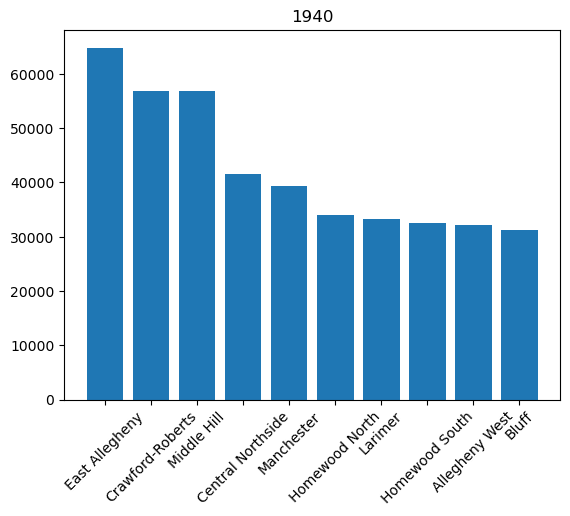

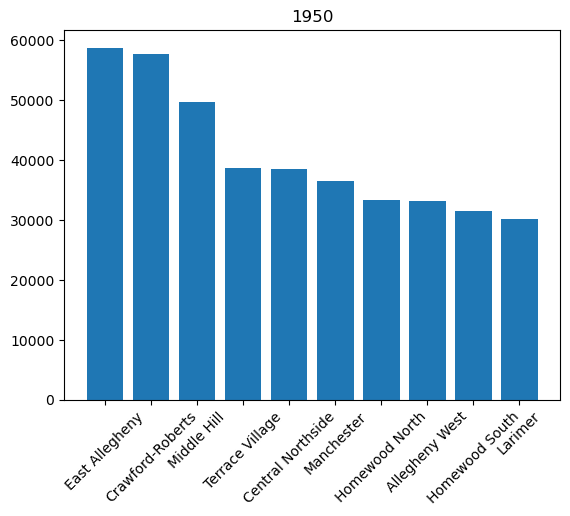

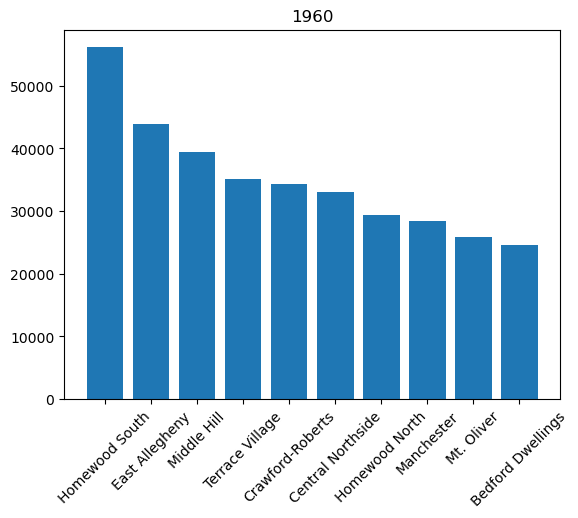

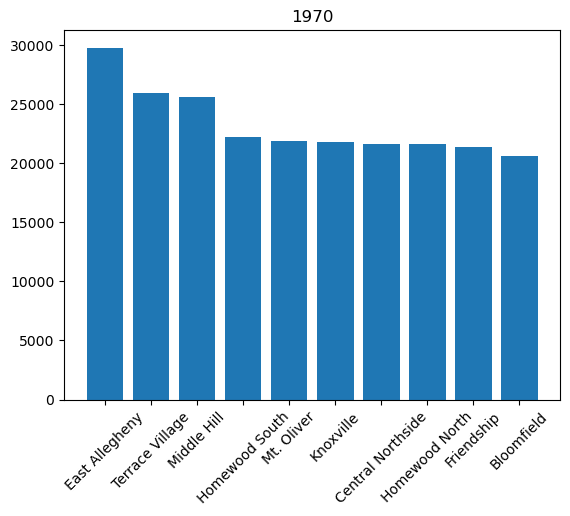

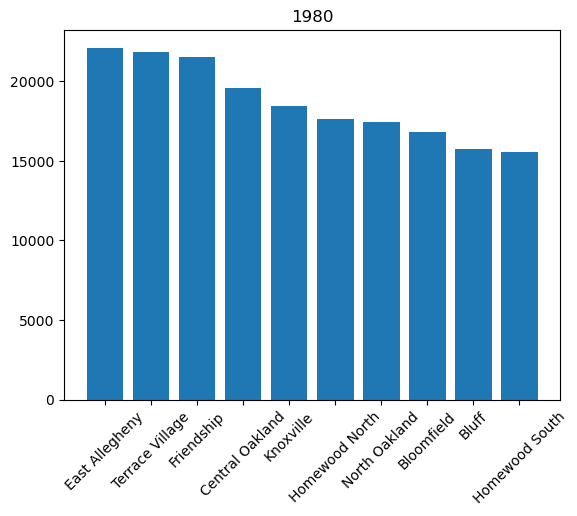

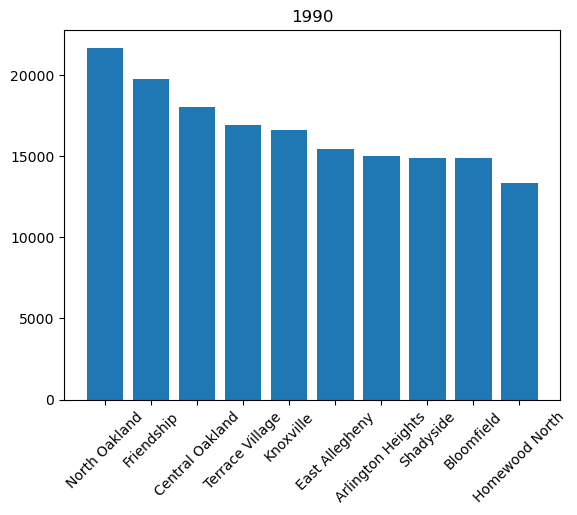

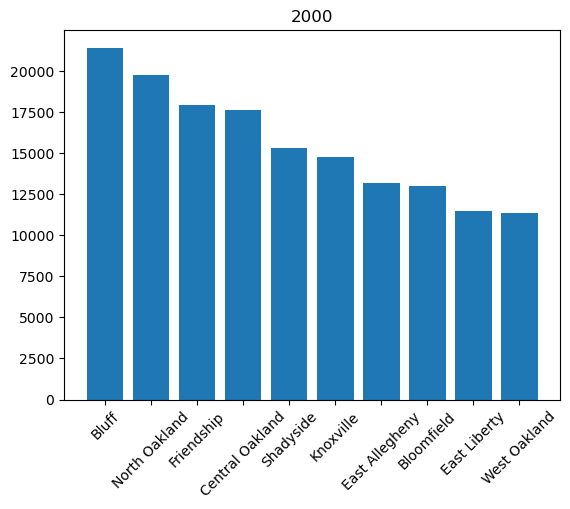

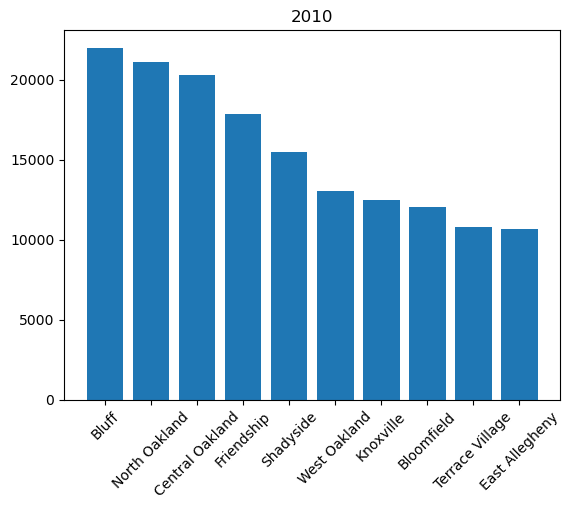

In [25]:
import matplotlib.pyplot as mp
for year in highest.keys():
    year_dict = highest[year]
    mp.title(year)
    mp.bar(year_dict.keys(),year_dict.values())
    mp.xticks(rotation=45)
    mp.show()
    print()
        

## Top ten lowest population densities each era.

In [26]:
lowest = {
    "1940" : {},
    "1950" : {},
    "1960" : {},
    "1970" : {},
    "1980" : {},
    "1990" : {},
    "2000" : {},
    "2010" : {}
}
for year in sorted_pd.keys():
    key_list = list(sorted_pd[year].keys())
    print(year)
    total_len = len(key_list)
    for i in range(10):
        j = total_len-i -1
        print(f"{key_list[j]} - {sorted_pd[year][key_list[j]]}")
        lowest[year][key_list[j]] = sorted_pd[year][key_list[j]]
    print()

1940
Windgap - 545.0
New Homestead - 861.25
South Shore - 920.0
Banksville - 1214.0
Hays - 1243.3333333333333
Fairywood - 1324.0
Northview Heights - 2206.666666666667
Ridgemont - 2210.0
Oakwood - 2456.666666666667
Swisshelm Park - 2676.0

1950
South Shore - 690.0
Hays - 1053.888888888889
New Homestead - 1217.5
Banksville - 1328.0
Windgap - 1850.0
Northview Heights - 2423.3333333333335
Ridgemont - 2472.5
Oakwood - 2583.3333333333335
Swisshelm Park - 2972.0
Westwood - 3757.1428571428573

1960
South Shore - 565.0
Hays - 864.4444444444445
New Homestead - 1381.25
Windgap - 1572.5
Northview Heights - 1756.6666666666667
Banksville - 2641.0
Ridgemont - 2647.5
Strip District - 2926.666666666667
East Carnegie - 3227.5
Central Business District - 3685.0

1970
South Shore - 435.0
Hays - 530.5555555555555
Windgap - 1335.0
Strip District - 1608.3333333333335
New Homestead - 1611.25
Chateau - 1702.5
North Shore - 2416.666666666667
East Carnegie - 2480.0
Glen Hazel - 3046.0
Allegheny Center - 3160.0



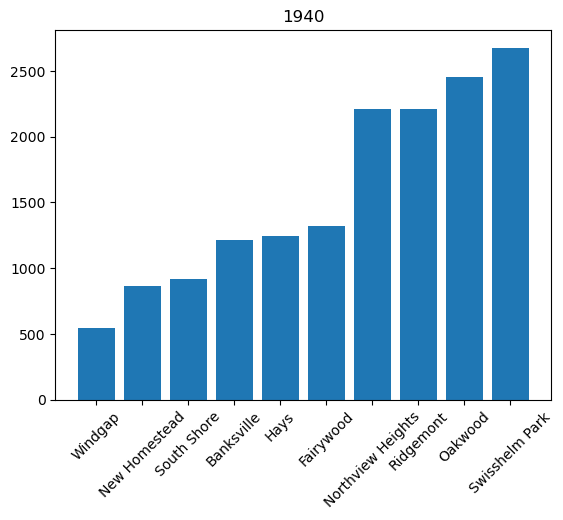

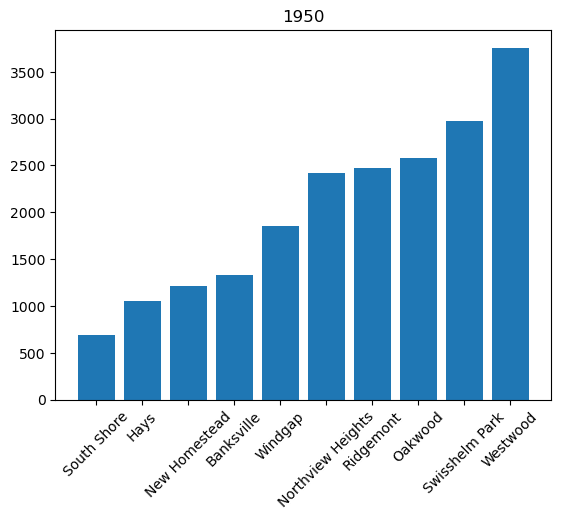

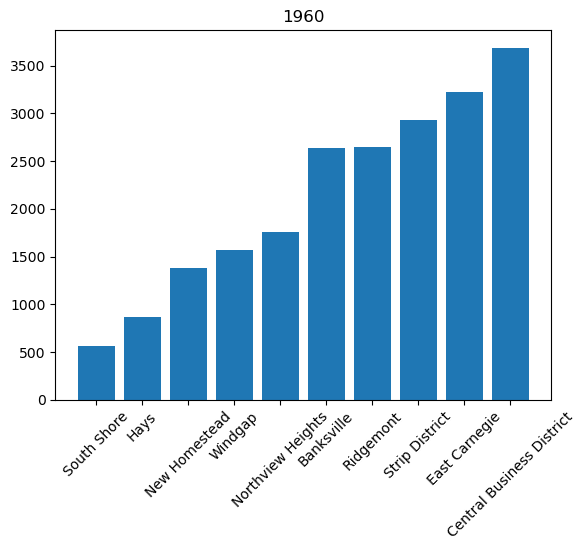

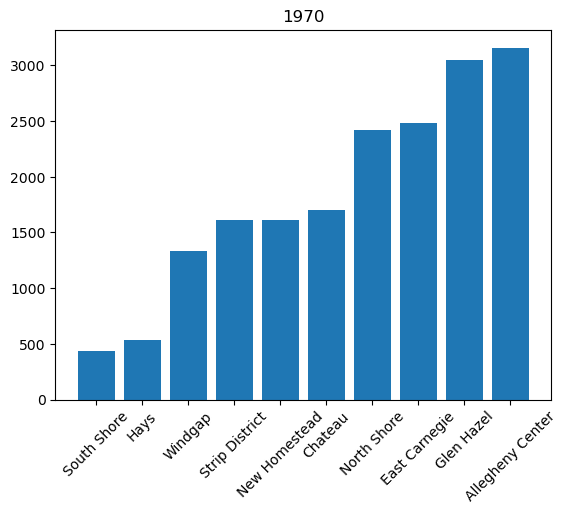

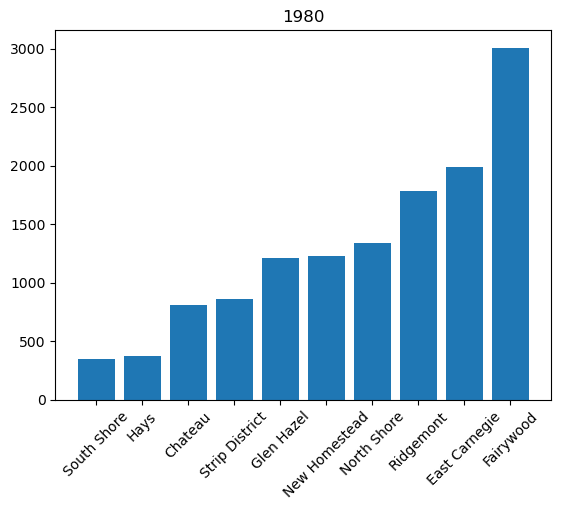

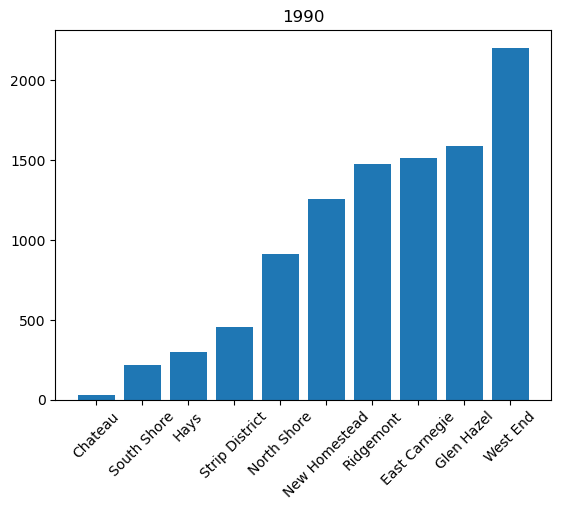

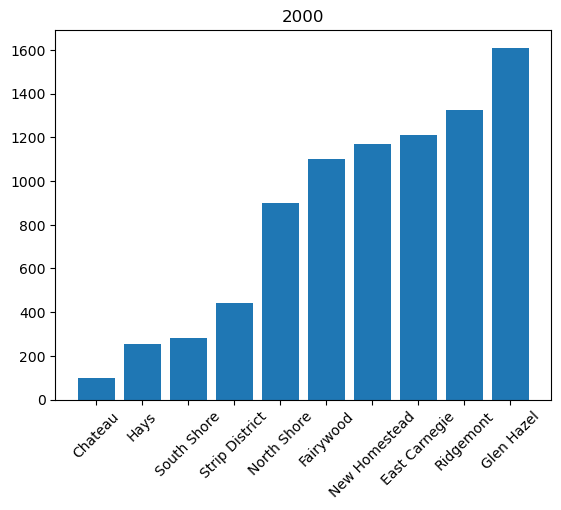

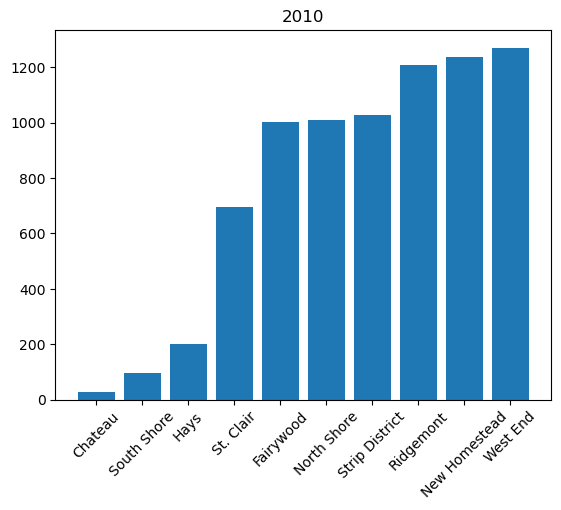

In [27]:
for year in lowest.keys():
    year_dict = lowest[year]
    mp.title(year)
    mp.bar(year_dict.keys(),year_dict.values())
    mp.xticks(rotation=45)
    mp.show()
    print()

## Initialize average population density in each section

In [19]:
avg = {
    "1940" : {},
    "1950" : {},
    "1960" : {},
    "1970" : {},
    "1980" : {},
    "1990" : {},
    "2000" : {},
    "2010" : {}
}
for year in sorted_pd.keys():
    for i in range(1,17):
        total = 0
        count = 0
        for city in sorted_pd[year].keys():
            if section[city] == i:
                total = total + sorted_pd[year][city] 
                count = count + 1
        s = str(i)
        avg[year][s] = total/count            

## All 16 sections average population density.  

In [20]:
for year in avg.keys():
    print(year)
    max_sect = None
    max_avg = 0
    min_sect = None
    min_avg = 1000000000
    for sect in avg[year].keys():
        if avg[year][sect] > max_avg:
            max_avg = avg[year][sect]
            max_sect = sect
        if avg[year][sect] < min_avg:
            min_avg = avg[year][sect]
            min_sect = sect
        print(f"Section #{sect} - {avg[year][sect]}")
    print(f"Min = #{min_sect} - {min_avg}")
    print(f"Max = #{max_sect} - {max_avg}")
    print()

1940
Section #1 - 9681.1
Section #2 - 11497.713189588188
Section #3 - 33076.145833333336
Section #4 - 5707.0859788359785
Section #5 - 6184.793137254902
Section #6 - 17426.022727272728
Section #7 - 16534.079365079364
Section #8 - 1784.5277777777776
Section #9 - 10900.208333333334
Section #10 - 6801.085185185186
Section #11 - 18946.416666666668
Section #12 - 21723.850198412696
Section #13 - 14552.563492063493
Section #14 - 17752.833333333336
Section #15 - 31991.38888888889
Section #16 - 10400.000000000002
Min = #8 - 1784.5277777777776
Max = #3 - 33076.145833333336

1950
Section #1 - 8994.666666666668
Section #2 - 11177.638888888889
Section #3 - 31044.166666666668
Section #4 - 6017.32208994709
Section #5 - 6706.053501400561
Section #6 - 16960.517676767675
Section #7 - 16827.79894179894
Section #8 - 2152.796296296296
Section #9 - 12107.291666666666
Section #10 - 7291.840740740741
Section #11 - 18859.203703703704
Section #12 - 22506.57341269841
Section #13 - 13003.702380952382
Section #14 -

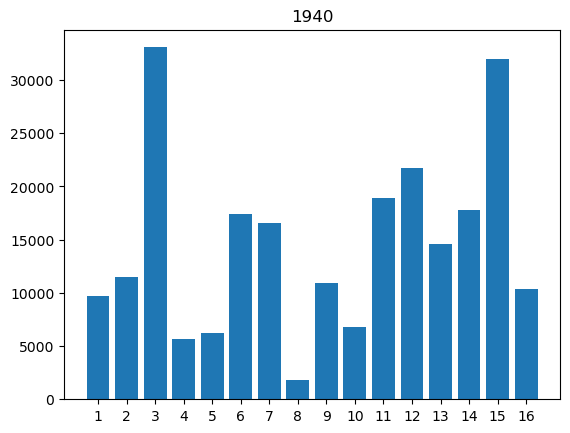

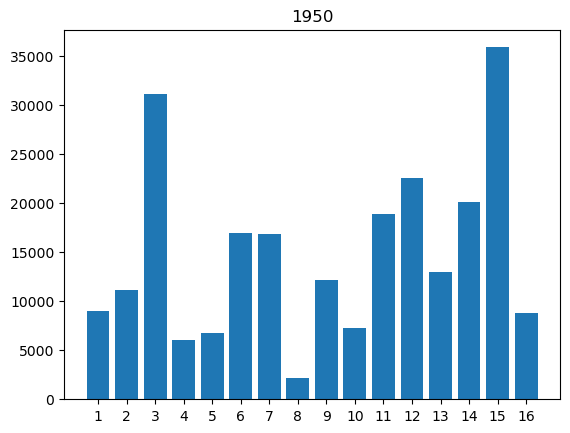

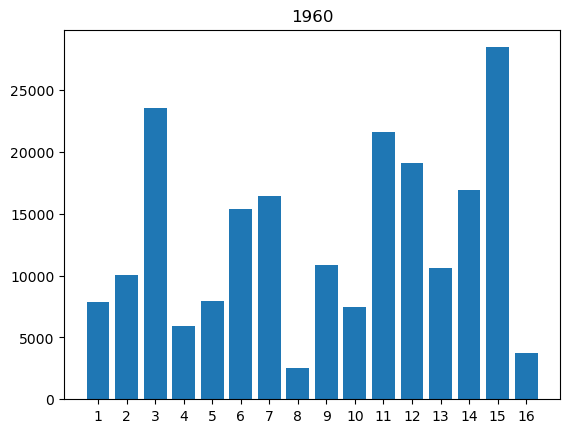

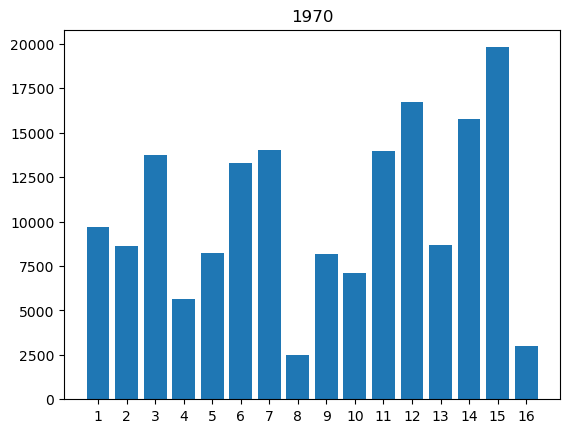

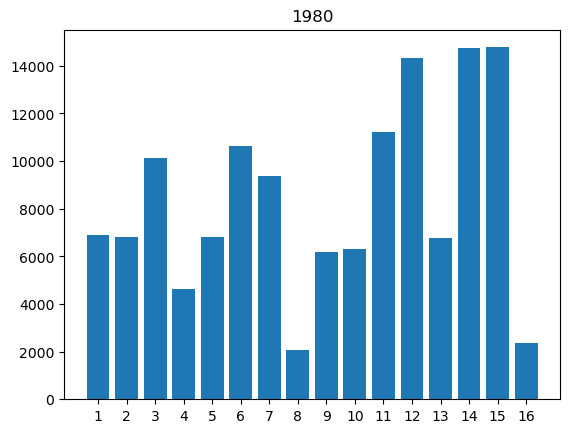

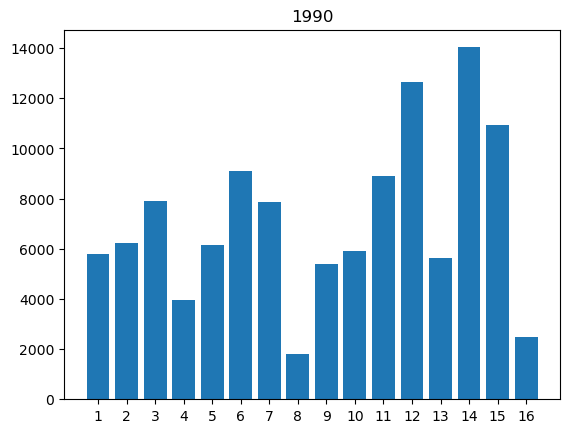

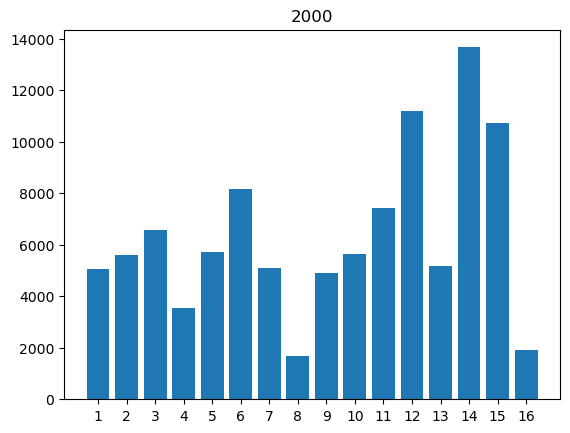

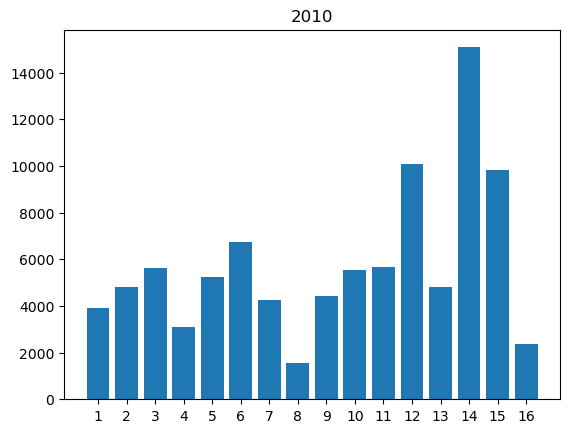

In [29]:
for year in avg.keys():
    year_dict = avg[year]
    mp.title(year)
    mp.bar(year_dict.keys(),year_dict.values())
    mp.show()
    print()

Based off of population density values, some of the safest places include Chateua, South Shore, New Homestead, Windgap, and Hays.  The most dangerous places include East Allegany, Bluff, North Oakland, and Homewood South.  The safest sections would include section #8 and section #16.  The most dangerous sections would be section #3, section #14, and section #15.  **The most dangerous place overall is East Allegany and dangerous section is section #14.  *The safest place is Chateua and safest section is section #8.***